# 09 - Risk Score, Explainability, and Temporal Trends

This notebook adds the main novelty layer on top of the hybrid plant disease model:

- Continuous disease risk score from 0 to 100
- Rule-based early warning alerts
- SHAP-based sensor contribution explainability
- Timestamp-based temporal health trend tracking


In [13]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    shap = None
    SHAP_AVAILABLE = False

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
os.makedirs('../../outputs/plots', exist_ok=True)

feature_order = [
    'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature',
    'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level',
    'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content',
    'Electrochemical_Signal'
]

hybrid_model = joblib.load('../../models/hybrid_stacking_model.pkl')
rf_model = joblib.load('../../models/random_forest_model.pkl')
scaler = joblib.load('../../models/scaler.pkl')
le = joblib.load('../../models/label_encoder.pkl')
X_train, X_test, y_train, y_test = joblib.load('../../models/splits.pkl')
raw_df = pd.read_csv('../../data/plant_health_data.csv')

class_names = list(le.classes_)
class_to_risk = {
    'Healthy': 0,
    'Moderate Stress': 50,
    'High Stress': 100
}

print('Hybrid model, RF model, scaler, encoder, and datasets loaded.')
print('Classes:', class_names)
print('SHAP available:', SHAP_AVAILABLE)


Hybrid model, RF model, scaler, encoder, and datasets loaded.
Classes: [np.str_('Healthy'), np.str_('Moderate Stress'), np.str_('High Stress')]
SHAP available: True


## Risk Score and Alert Logic

The risk score is computed from predicted class probabilities, but the weighting is mapped by the saved label names so it stays correct even if class order changes.


In [14]:
def compute_risk_score(probabilities, class_labels):
    weights = np.array([class_to_risk[label] for label in class_labels], dtype=float)
    return round(float(np.dot(probabilities, weights)), 2)


def alert_from_score(score):
    if score >= 75:
        return 'CRITICAL - Take immediate action'
    if score >= 40:
        return 'WARNING - Monitor closely'
    return 'SAFE - Plant is healthy'


def predict_with_novelty(sensor_readings):
    input_df = pd.DataFrame([sensor_readings])[feature_order]
    input_scaled = scaler.transform(input_df)
    probabilities = hybrid_model.predict_proba(input_scaled)[0]
    pred_idx = int(np.argmax(probabilities))
    predicted_label = class_names[pred_idx]
    confidence = round(float(probabilities[pred_idx] * 100), 2)
    risk_score = compute_risk_score(probabilities, class_names)
    alert = alert_from_score(risk_score)

    probability_table = pd.DataFrame({
        'Class': class_names,
        'Probability': np.round(probabilities, 4),
        'Risk_Weight': [class_to_risk[label] for label in class_names]
    }).sort_values('Probability', ascending=False).reset_index(drop=True)

    summary = {
        'Predicted_Status': predicted_label,
        'Confidence_%': confidence,
        'Risk_Score_0_100': risk_score,
        'Alert': alert
    }
    return summary, probability_table, input_df, input_scaled


In [15]:
sample_moderate = {
    'Soil_Moisture': 32.0,
    'Ambient_Temperature': 29.0,
    'Soil_Temperature': 27.0,
    'Humidity': 71.0,
    'Light_Intensity': 420.0,
    'Soil_pH': 5.7,
    'Nitrogen_Level': 28.0,
    'Phosphorus_Level': 20.0,
    'Potassium_Level': 24.0,
    'Chlorophyll_Content': 22.0,
    'Electrochemical_Signal': 0.68
}

summary, probability_table, input_df, input_scaled = predict_with_novelty(sample_moderate)
print(pd.Series(summary))
probability_table


Predicted_Status                    Healthy
Confidence_%                          92.39
Risk_Score_0_100                        4.8
Alert               SAFE - Plant is healthy
dtype: object


,Class,Probability,Risk_Weight
0,Healthy,0.9239,0
1,Moderate Stress,0.0561,50
2,High Stress,0.0199,100


## Batch Risk Scoring on Test Samples

This section shows how the novelty layer behaves on multiple test instances from the saved split.


In [16]:
sample_count = 10
test_proba = hybrid_model.predict_proba(X_test[:sample_count])
test_pred = hybrid_model.predict(X_test[:sample_count])

risk_scores = [compute_risk_score(proba, class_names) for proba in test_proba]
alerts = [alert_from_score(score) for score in risk_scores]

batch_results = pd.DataFrame(X_test[:sample_count], columns=feature_order)
batch_results['Actual_Label'] = le.inverse_transform(y_test[:sample_count])
batch_results['Predicted_Label'] = le.inverse_transform(test_pred)
batch_results['Risk_Score'] = risk_scores
batch_results['Alert'] = alerts
batch_results[['Actual_Label', 'Predicted_Label', 'Risk_Score', 'Alert']]


,Actual_Label,Predicted_Label,Risk_Score,Alert
0,Healthy,Healthy,1.40,SAFE - Plant is healthy
1,High Stress,High Stress,99.28,CRITICAL - Take immediate action
2,Healthy,Healthy,1.38,SAFE - Plant is healthy
3,Healthy,Healthy,0.82,SAFE - Plant is healthy
4,Healthy,Healthy,0.27,SAFE - Plant is healthy
5,Moderate Stress,Moderate Stress,49.92,WARNING - Monitor closely
6,Healthy,Healthy,0.73,SAFE - Plant is healthy
7,High Stress,High Stress,97.93,CRITICAL - Take immediate action
8,High Stress,High Stress,99.75,CRITICAL - Take immediate action
9,Healthy,Healthy,0.83,SAFE - Plant is healthy


## Explainability with SHAP

SHAP is applied to the Random Forest base model to show which sensors drive the decision. This is useful because tree-based SHAP is fast and directly interpretable at the sensor level.


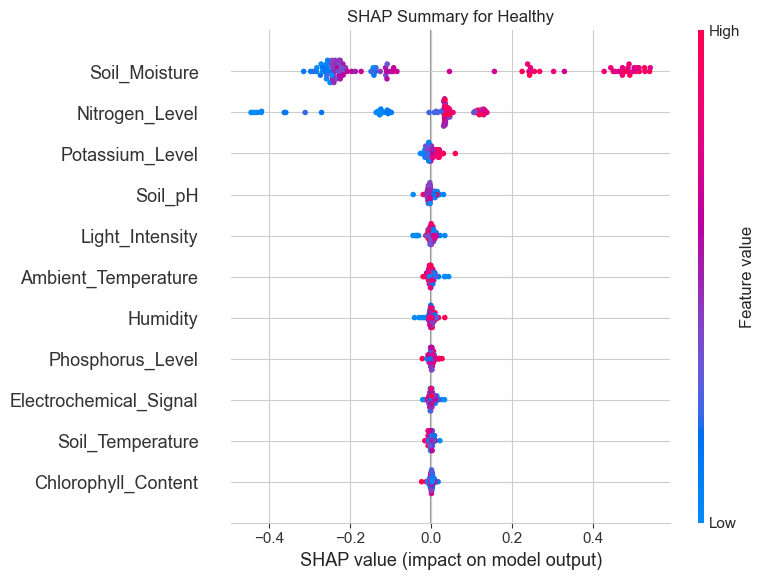

Top sensor contributions for the explained sample:


,Feature,SHAP_Value,Abs_SHAP
0,Soil_Moisture,0.472964,0.472964
1,Nitrogen_Level,0.106534,0.106534
2,Humidity,-0.030130,0.030130
3,Potassium_Level,-0.013431,0.013431
4,Light_Intensity,-0.013107,0.013107
5,Ambient_Temperature,0.005601,0.005601
6,Phosphorus_Level,0.002307,0.002307
7,Soil_Temperature,0.002204,0.002204


In [17]:
explain_idx = 0
X_test_df = pd.DataFrame(X_test, columns=feature_order)
X_explain = X_test_df.iloc[[explain_idx]]

if not SHAP_AVAILABLE:
    print('SHAP is not installed. Using Random Forest feature importance fallback instead.')
    sample_contrib = pd.DataFrame({
        'Feature': feature_order,
        'Importance': rf_model.feature_importances_,
        'Abs_SHAP': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=sample_contrib.head(10), x='Importance', y='Feature', hue='Feature', legend=False, palette='viridis')
    plt.title('Random Forest Feature Importance Fallback')
    plt.tight_layout()
    plt.savefig('../../outputs/plots/shap_summary_rf.png', dpi=150)
    plt.show()
else:
    explainer = shap.TreeExplainer(rf_model)
    shap_values = explainer.shap_values(X_test_df.iloc[:100])
    single_shap = explainer.shap_values(X_explain)
    class_index = int(rf_model.predict(X_explain)[0])

    if isinstance(shap_values, list):
        summary_values = shap_values[class_index]
        sample_values = single_shap[class_index][0]
    else:
        shap_values = np.asarray(shap_values)
        single_shap = np.asarray(single_shap)

        if shap_values.ndim == 3:
            summary_values = shap_values[:, :, class_index]
            sample_values = single_shap[0, :, class_index]
        elif shap_values.ndim == 2:
            summary_values = shap_values
            sample_values = single_shap[0]
        else:
            raise ValueError(f'Unexpected SHAP output shape: {shap_values.shape}')

    shap.summary_plot(summary_values, X_test_df.iloc[:100], show=False)
    plt.title(f'SHAP Summary for {class_names[class_index]}')
    plt.tight_layout()
    plt.savefig('../../outputs/plots/shap_summary_rf.png', dpi=150)
    plt.show()

    sample_contrib = pd.DataFrame({
        'Feature': feature_order,
        'SHAP_Value': sample_values,
        'Abs_SHAP': np.abs(sample_values)
    }).sort_values('Abs_SHAP', ascending=False).reset_index(drop=True)

print('Top sensor contributions for the explained sample:')
display(sample_contrib.head(8))


## Temporal Health Trend Analysis

The raw dataset contains a timestamp every few hours. Here we convert plant health status into a severity score and track the trend over time.


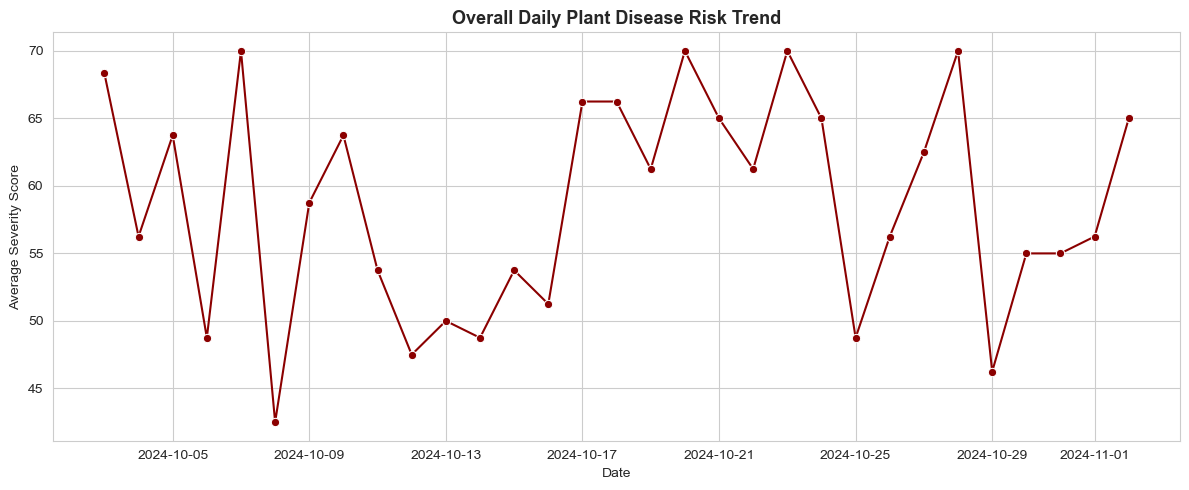

,Timestamp,Severity_Score
26,2024-10-29,46.25
27,2024-10-30,55.00
28,2024-10-31,55.00
29,2024-11-01,56.25
30,2024-11-02,65.00


In [18]:
raw_df['Timestamp'] = pd.to_datetime(raw_df['Timestamp'])
raw_df['Severity_Score'] = raw_df['Plant_Health_Status'].map(class_to_risk)

daily_trend = (
    raw_df.groupby(pd.Grouper(key='Timestamp', freq='D'))['Severity_Score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_trend, x='Timestamp', y='Severity_Score', marker='o', color='darkred')
plt.title('Overall Daily Plant Disease Risk Trend', fontsize=13, fontweight='bold')
plt.ylabel('Average Severity Score')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('../../outputs/plots/temporal_risk_trend.png', dpi=150)
plt.show()

daily_trend.tail()


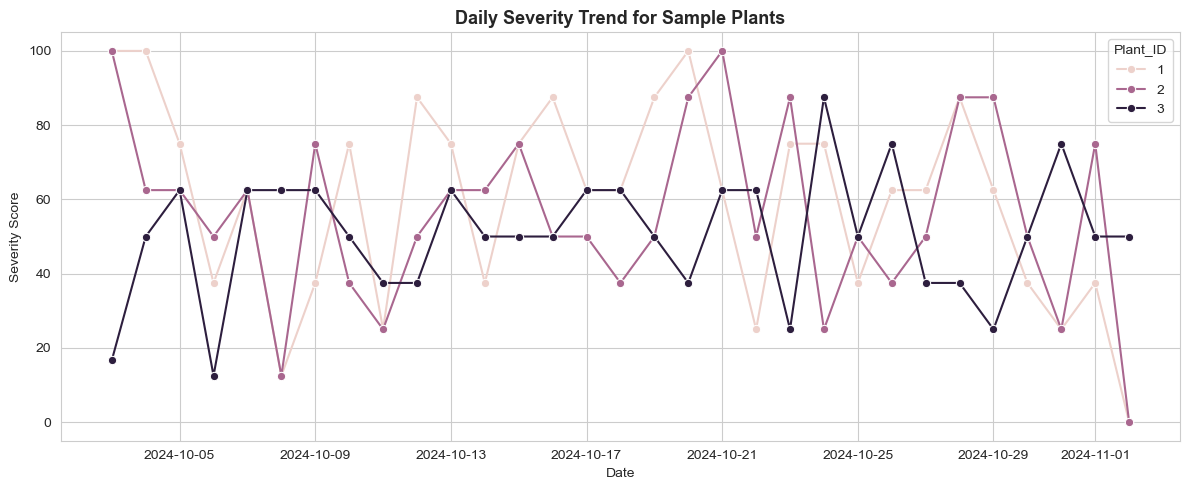

In [19]:
top_plants = raw_df['Plant_ID'].value_counts().head(3).index.tolist()
plant_trend = (
    raw_df[raw_df['Plant_ID'].isin(top_plants)]
    .groupby(['Plant_ID', pd.Grouper(key='Timestamp', freq='D')])['Severity_Score']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=plant_trend, x='Timestamp', y='Severity_Score', hue='Plant_ID', marker='o')
plt.title('Daily Severity Trend for Sample Plants', fontsize=13, fontweight='bold')
plt.ylabel('Severity Score')
plt.xlabel('Date')
plt.legend(title='Plant_ID')
plt.tight_layout()
plt.savefig('../../outputs/plots/plant_level_temporal_trend.png', dpi=150)
plt.show()
